In [14]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/GOOG.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.dropna()

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [17]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,3774,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,2016-07-01 03:40:32.432432,50.779971,51.285163,50.252347,50.753534,6.123096e+07
min,2009-01-02 00:00:00,6.994490,7.408840,6.994490,7.133018,1.584340e+05
25%,2012-09-28 18:00:00,16.851089,16.984424,16.699388,16.827651,2.574863e+07
50%,2016-06-30 12:00:00,37.327805,37.647668,37.038786,37.388390,3.797798e+07
75%,2020-03-31 18:00:00,69.191502,70.084894,68.368832,69.062883,8.269781e+07
max,2023-12-29 00:00:00,149.684662,151.066223,148.868758,150.831319,5.952147e+08
std,NaN,39.417443,39.853299,38.975050,39.389736,5.537396e+07


In [18]:
# moving average
#SMA
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
#EMA
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()


In [19]:
# RSI
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

In [20]:
# MACD
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

Visualization

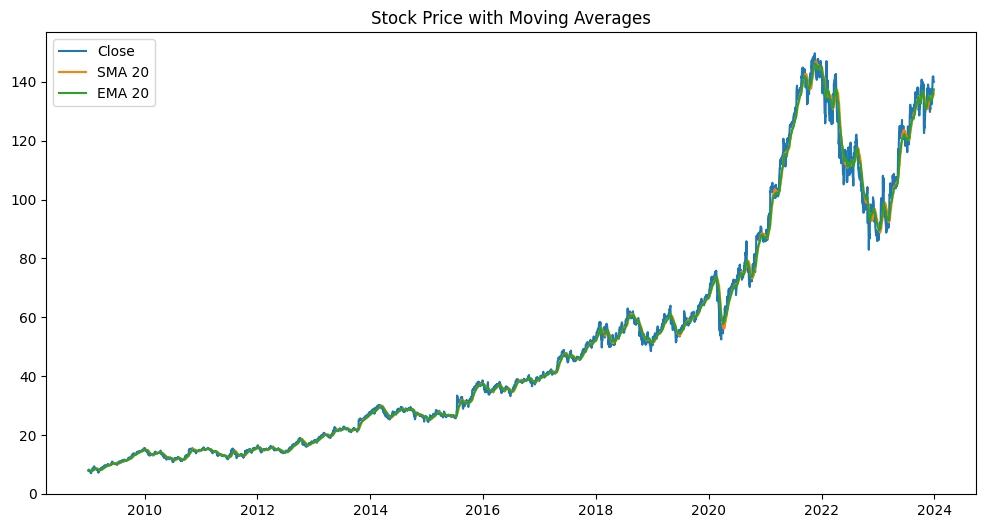

In [21]:
# Price and moving average

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

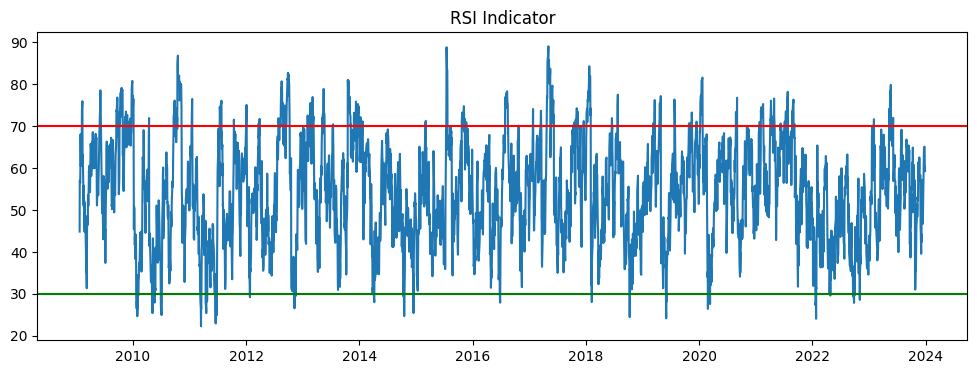

In [22]:
# RSI plot 
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['RSI'])

plt.axhline(70, color='red')
plt.axhline(30, color='green')

plt.title("RSI Indicator")
plt.show()

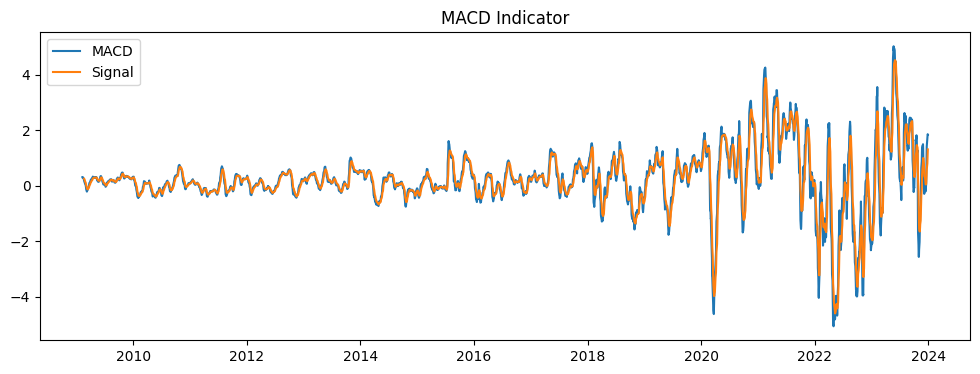

In [23]:
# MACD Plot
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal')

plt.legend()
plt.title("MACD Indicator")
plt.show()

PyNance was intended to be used for financial metric computation. Due to compatibility issues with pandas_datareader, equivalent financial indicators were computed manually using pandas and numpy. These include daily returns, rolling volatility (20-day window), log returns, and drawdown, which are standard outputs consistent with PyNance financial analysis functionality.

In [24]:

df['returns'] = df['Close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [25]:
df.tail()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,returns,volatility,log_returns
3769,2023-12-22,141.750000,142.276397,141.089511,141.164014,18513500,135.009596,133.914786,135.854576,64.953309,1.412015,0.572046,0.006488,0.017215,0.006467
3770,2023-12-26,141.849304,142.966658,141.531472,142.008205,11170100,135.246477,133.999010,136.425503,65.115870,1.706565,0.798950,0.000701,0.017203,0.000700
3771,2023-12-27,140.478683,142.345911,140.092320,141.859236,17288400,135.386520,134.017881,136.811520,60.916026,1.808553,1.000870,-0.009663,0.017382,-0.009709
3772,2023-12-28,140.319748,141.303025,139.870824,140.885881,12192500,135.628861,134.023641,137.145637,60.429303,1.855168,1.171730,-0.001131,0.016921,-0.001132
3773,2023-12-29,139.972137,140.473710,138.949139,139.723837,14881000,135.976979,134.056417,137.414827,59.313063,1.842820,1.305948,-0.002477,0.016293,-0.002480


In [26]:
df.to_csv("../data/GOOG_processed.csv")